In [8]:
# Import libraries
from pathlib import Path

import geopandas as gpd

In [9]:
# Input and output paths
ROOT      = Path().resolve().parent
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
PROCESSED.mkdir(parents=True, exist_ok=True)

In [10]:
"""
    Download: https://service.pdok.nl/kadaster/brk-administratieve-eenheden/atom/downloads/administrativeunits.zip
    Unzip and place administrativeunits.gml in this folder (data/raw/)
"""

gdf = gpd.read_file(RAW / "administrativeunits.gml", layer="AdministrativeUnit")

print("New Columns:")
print(list(gdf.columns))

New Columns:
['gml_id', 'nationalCode', 'localId', 'namespace', 'LocalisedCharacterString', 'Country', 'language', 'sourceOfName', 'pronunciation', 'text', 'script', 'transliterationScheme', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|language', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|sourceOfName', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|spelling|SpellingOfName|script', 'geometry', 'beginLifespanVersion', 'boundary', 'residenceOfAuthority|ResidenceOfAuthority|name|GeographicalName|spelling|SpellingOfName|text']


In [11]:
# Filter for entries containing "Utrecht"
utrecht_gdf = gdf[gdf['text'].str.contains("Utrecht", case=False, na=False)]

print("Found the following regions:")
print(utrecht_gdf[['gml_id', 'text', 'nationalCode']])


Found the following regions:
                 gml_id                 text nationalCode
77   nl-imkad-au.GM0344              Utrecht         0344
108  nl-imkad-au.GM1581  Utrechtse Heuvelrug         1581
346    nl-imkad-au.PV26              Utrecht           26


In [12]:
# Filter for just the city/municipality
utrecht_city = utrecht_gdf[utrecht_gdf['nationalCode'] == '0344']
print(utrecht_city.crs) 

# Filter for just the province
utrecht_province = utrecht_gdf[utrecht_gdf['nationalCode'] == '26']
print(utrecht_province.crs) 

EPSG:4258
EPSG:4258


In [13]:
# Reproject to RD New (EPSG:28992)
utrecht_city = utrecht_city.to_crs(epsg=28992)
print(utrecht_city.crs) 
utrecht_province = utrecht_province.to_crs(epsg=28992)
print(utrecht_province.crs) 

EPSG:28992
EPSG:28992


C:\Users\sadar\AppData\Local\Temp\ipykernel_15856\3919120382.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  utrecht_city.to_file(PROCESSED / "utrecht_city.shp", driver="ESRI Shapefile")
c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'nationalCode' to 'nationalCo'
  ogr_write(
c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'LocalisedCharacterString' to 'LocalisedC'
  ogr_write(
c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'sourceOfName' to 'sourceOfNa'
  ogr_write(
c:\Users\sadar\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'pronunciation' to 'pronunciat'
  ogr_wri

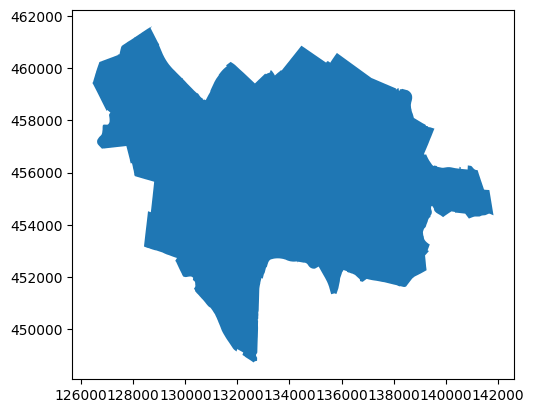

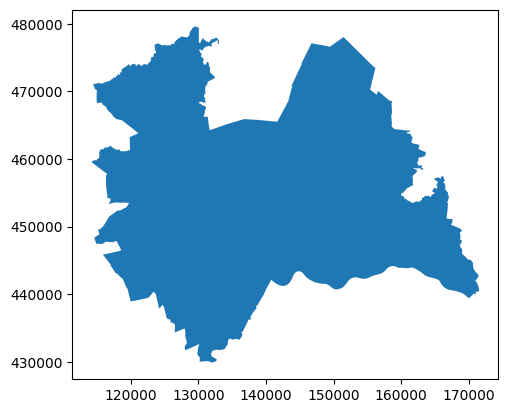

In [14]:
utrecht_city.plot()
utrecht_province.plot()

utrecht_city.to_file(PROCESSED / "utrecht_city.shp", driver="ESRI Shapefile")
utrecht_province.to_file(PROCESSED / "utrecht_province.shp", driver="ESRI Shapefile")